# MLflow preliminary analysis

Read-only notebook for analyzing training runs from local `mlruns/`.

It filters MLflow experiments by names containing `Preliminary` / `PreliminaryTDA` and produces:
- `runs_df` summary with extracted parameters
- `best_metrics_table` (mean/std across seeds)
- learning curves (time-series) for `loss_train` and `loss_val`



In [11]:
import os
import re
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

import mlflow
from mlflow.tracking import MlflowClient

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

# Assume notebook lives in <repo>/notebooks
NOTEBOOK_CWD = Path.cwd()
ROOT = NOTEBOOK_CWD if (NOTEBOOK_CWD / "mlruns").is_dir() else NOTEBOOK_CWD.parent

# MLflow tracking URI: point explicitly to <root>/mlruns unless overridden
default_mlruns = ROOT / "mlruns"
tracking_uri = os.environ.get("MLFLOW_TRACKING_URI", f"file:{default_mlruns}")

runs_cache_dir = ROOT / ".cache" / "mlflow_preliminary_analysis"
runs_cache_dir.mkdir(parents=True, exist_ok=True)

print("ROOT=", ROOT)
print("tracking_uri=", tracking_uri)
print("cache_dir=", str(runs_cache_dir))


ROOT= /Users/musik/Documents/education/tda-of-digital-images
tracking_uri= file:/Users/musik/Documents/education/tda-of-digital-images/mlruns
cache_dir= /Users/musik/Documents/education/tda-of-digital-images/.cache/mlflow_preliminary_analysis


In [13]:
client = MlflowClient(tracking_uri=tracking_uri)

from mlflow.entities.view_type import ViewType
experiments = client.search_experiments(view_type=ViewType.ALL, max_results=50000)

prelim_re = re.compile(r"PreliminaryTDA|Preliminary", re.IGNORECASE)

prelim_exps = []
for e in experiments:
    name = e.name or ""
    if prelim_re.search(name):
        prelim_exps.append(e)

print("Total experiments:", len(experiments))
print("Preliminary experiments:", len(prelim_exps))
print("Preliminary experiment names (sample):", [e.name for e in prelim_exps[:5]])

records = []

# Helper: MLflow params/values are typically strings.
def _p(d: Dict, k: str):
    v = d.get(k)
    if v is None:
        return None
    return str(v)

for e in prelim_exps:
    exp_id = e.experiment_id
    exp_name = e.name
    # Local mlruns can have many runs; keep a high cap.
    runs = client.search_runs(experiment_ids=[exp_id], max_results=50000)
    for r in runs:
        p = r.data.params or {}
        dataset = _p(p, "dataset")
        seed = _p(p, "seed")
        model = _p(p, "model")
        transform = _p(p, "transform")
        power = _p(p, "power")
        idx = _p(p, "idx")
        eps = _p(p, "eps")

        method = model  # в текущих раннерах model обычно и есть метод

        # config_key нужен для группировки графиков по конфигурации (без seed)
        config_key = "|".join(
            [x if x is not None else "NA" for x in [dataset, model, transform, power, idx, eps, method]]
        )

        records.append(
            {
                "run_id": r.info.run_id,
                "experiment_id": exp_id,
                "experiment_name": exp_name,
                "dataset": dataset,
                "seed": seed,
                "model": model,
                "transform": transform,
                "power": power,
                "idx": idx,
                "eps": eps,
                "method": method,
                "config_key": config_key,
            }
        )

runs_df = pd.DataFrame.from_records(records)

print("runs_df rows:", len(runs_df))
if len(runs_df) > 0:
    display(runs_df.head(3))

# Convenience types
for col in ["seed", "power", "idx", "eps"]:
    if col in runs_df.columns:
        runs_df[col] = pd.to_numeric(runs_df[col], errors="ignore")


Total experiments: 6
Preliminary experiments: 5
Preliminary experiment names (sample): ['PERSFORMER_PreliminaryTDA_mnist_clean', 'DeepSets_PreliminaryTDA_mnist_clean', 'FixedEncodersPS_PreliminaryTDA_mnist_clean', 'FixedEncodersPL_PreliminaryTDA_mnist_clean', 'FixedEncodersPI_PreliminaryTDA_mnist_clean']
runs_df rows: 7


,run_id,experiment_id,experiment_name,dataset,seed,model,transform,power,idx,eps,method,config_key
0,26c1a18734d04fe5b1c0c9b6aba9f946,608242818132028843,PERSFORMER_PreliminaryTDA_mnist_clean,MNIST,0,LATENT_PERSFORMER,None,0.0,"[0, 2, 4, 6, 7, 9, 11, 13, 16]",0.02,LATENT_PERSFORMER,"MNIST|LATENT_PERSFORMER|None|0.0|[0, 2, 4, 6, ..."
1,f2859d4adda148198b01fcde301e1c3d,608242818132028843,PERSFORMER_PreliminaryTDA_mnist_clean,MNIST,0,LINEAR_PERSFORMER,None,0.0,"[0, 2, 4, 6, 7, 9, 11, 13, 16]",0.02,LINEAR_PERSFORMER,"MNIST|LINEAR_PERSFORMER|None|0.0|[0, 2, 4, 6, ..."
2,d33ea0f7955446769e50b6ce9ff0f02c,608242818132028843,PERSFORMER_PreliminaryTDA_mnist_clean,MNIST,0,PERSFORMER,None,0.0,"[0, 2, 4, 6, 7, 9, 11, 13, 16]",0.02,PERSFORMER,"MNIST|PERSFORMER|None|0.0|[0, 2, 4, 6, 7, 9, 1..."


/var/folders/sw/4qr_mf6j4xjfzk43fvclv4w00000gn/T/ipykernel_99814/3094501010.py:75: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  runs_df[col] = pd.to_numeric(runs_df[col], errors="ignore")


In [14]:
# --- Cell 3: Extract time-series metrics ---

required_series_metrics = [
    "loss_train",
    "loss_val",
]

# Optional scalar/best metric
best_metric_key = "acc_test_at_val_best"

unique_run_ids = runs_df["run_id"].dropna().unique().tolist()
print("Unique preliminary run_ids:", len(unique_run_ids))


def _history_to_df(hist):
    # hist: list[mlflow.entities.Metric]
    if not hist:
        return pd.DataFrame(columns=["step", "value"])
    rows = [{"step": m.step, "value": m.value} for m in hist]
    df = pd.DataFrame(rows)
    # Ensure numeric ordering
    df = df.sort_values("step")
    return df


def load_metric_history_cached(run_id: str, metric_key: str) -> pd.DataFrame:
    cache_file = runs_cache_dir / f"{run_id}__{metric_key}.csv"
    if cache_file.exists():
        try:
            return pd.read_csv(cache_file)
        except Exception:
            pass

    hist = client.get_metric_history(run_id, metric_key)
    df = _history_to_df(hist)

    # Cache even if empty (so we don't call MLflow again)
    try:
        df.to_csv(cache_file, index=False)
    except Exception:
        pass

    return df


# Extract series for each run + metric.
series_records = []

for i, run_id in enumerate(unique_run_ids):
    if (i % 10) == 0:
        print(f"Series extraction: {i}/{len(unique_run_ids)}")

    run_rows = runs_df[runs_df["run_id"] == run_id]
    if run_rows.empty:
        continue

    row0 = run_rows.iloc[0]
    config_key = row0["config_key"]
    dataset = row0["dataset"]
    seed = row0["seed"]
    model = row0["model"]

    for metric_key in required_series_metrics:
        df_hist = load_metric_history_cached(run_id, metric_key)
        if df_hist.empty:
            continue

        df_hist = df_hist.copy()
        df_hist["run_id"] = run_id
        df_hist["config_key"] = config_key
        df_hist["dataset"] = dataset
        df_hist["seed"] = seed
        df_hist["model"] = model
        df_hist["metric_key"] = metric_key

        series_records.append(df_hist)


series_df = pd.concat(series_records, ignore_index=True) if series_records else pd.DataFrame()
print("series_df empty?", series_df.empty)
if not series_df.empty:
    display(series_df.head(10))

# Basic coverage stats
if not series_df.empty:
    cov = (
        series_df.groupby(["config_key", "metric_key"], as_index=False)["value"]
        .count()
        .rename(columns={"value": "n_points"})
    )
    print("Series coverage (top 10):")
    display(cov.sort_values("n_points", ascending=False).head(10))


Unique preliminary run_ids: 7
Series extraction: 0/7
series_df empty? False


,step,value,run_id,config_key,dataset,seed,model,metric_key
0,0,1.195954,26c1a18734d04fe5b1c0c9b6aba9f946,"MNIST|LATENT_PERSFORMER|None|0.0|[0, 2, 4, 6, ...",MNIST,0,LATENT_PERSFORMER,loss_train
1,0,0.724306,26c1a18734d04fe5b1c0c9b6aba9f946,"MNIST|LATENT_PERSFORMER|None|0.0|[0, 2, 4, 6, ...",MNIST,0,LATENT_PERSFORMER,loss_val
2,0,1.149308,d33ea0f7955446769e50b6ce9ff0f02c,"MNIST|PERSFORMER|None|0.0|[0, 2, 4, 6, 7, 9, 1...",MNIST,0,PERSFORMER,loss_train
3,0,0.642860,d33ea0f7955446769e50b6ce9ff0f02c,"MNIST|PERSFORMER|None|0.0|[0, 2, 4, 6, 7, 9, 1...",MNIST,0,PERSFORMER,loss_val
4,0,1.742886,787020f8c907407cb2eefbe4a0ef35b3,"MNIST|PHTS|None|0.0|[0, 2, 4, 6, 7, 9, 11, 13,...",MNIST,0,PHTS,loss_train
5,0,1.127279,787020f8c907407cb2eefbe4a0ef35b3,"MNIST|PHTS|None|0.0|[0, 2, 4, 6, 7, 9, 11, 13,...",MNIST,0,PHTS,loss_val
6,0,2.050841,e59a45d6656743fbb9982ba954e45e4c,"MNIST|NA|None|0.0|[0, 2, 4, 6, 7, 9, 11, 13, 1...",MNIST,0,None,loss_train
7,0,1.878186,e59a45d6656743fbb9982ba954e45e4c,"MNIST|NA|None|0.0|[0, 2, 4, 6, 7, 9, 11, 13, 1...",MNIST,0,None,loss_val
8,0,1.938358,4d40c95553b446709cadb842d8023532,"MNIST|NA|None|0.0|[0, 2, 4, 6, 7, 9, 11, 13, 1...",MNIST,0,None,loss_train
9,0,1.710350,4d40c95553b446709cadb842d8023532,"MNIST|NA|None|0.0|[0, 2, 4, 6, 7, 9, 11, 13, 1...",MNIST,0,None,loss_val


Series coverage (top 10):


,config_key,metric_key,n_points
2,"MNIST|NA|None|0.0|[0, 2, 4, 6, 7, 9, 11, 13, 1...",loss_train,3
3,"MNIST|NA|None|0.0|[0, 2, 4, 6, 7, 9, 11, 13, 1...",loss_val,3
0,"MNIST|LATENT_PERSFORMER|None|0.0|[0, 2, 4, 6, ...",loss_train,1
1,"MNIST|LATENT_PERSFORMER|None|0.0|[0, 2, 4, 6, ...",loss_val,1
4,"MNIST|PERSFORMER|None|0.0|[0, 2, 4, 6, 7, 9, 1...",loss_train,1
5,"MNIST|PERSFORMER|None|0.0|[0, 2, 4, 6, 7, 9, 1...",loss_val,1
6,"MNIST|PHTS|None|0.0|[0, 2, 4, 6, 7, 9, 11, 13,...",loss_train,1
7,"MNIST|PHTS|None|0.0|[0, 2, 4, 6, 7, 9, 11, 13,...",loss_val,1


Best extraction: 0/7
best_df rows: 7
Non-null best: 6
Top configs by best acc:


,config_key,best_mean,best_std,n_seeds,dataset,model
2,"MNIST|PERSFORMER|None|0.0|[0, 2, 4, 6, 7, 9, 1...",0.823746,NaN,1,MNIST,PERSFORMER
0,"MNIST|LATENT_PERSFORMER|None|0.0|[0, 2, 4, 6, ...",0.781648,NaN,1,MNIST,LATENT_PERSFORMER
3,"MNIST|PHTS|None|0.0|[0, 2, 4, 6, 7, 9, 11, 13,...",0.654371,NaN,1,MNIST,PHTS
1,"MNIST|NA|None|0.0|[0, 2, 4, 6, 7, 9, 11, 13, 1...",0.361056,0.045124,3,MNIST,None


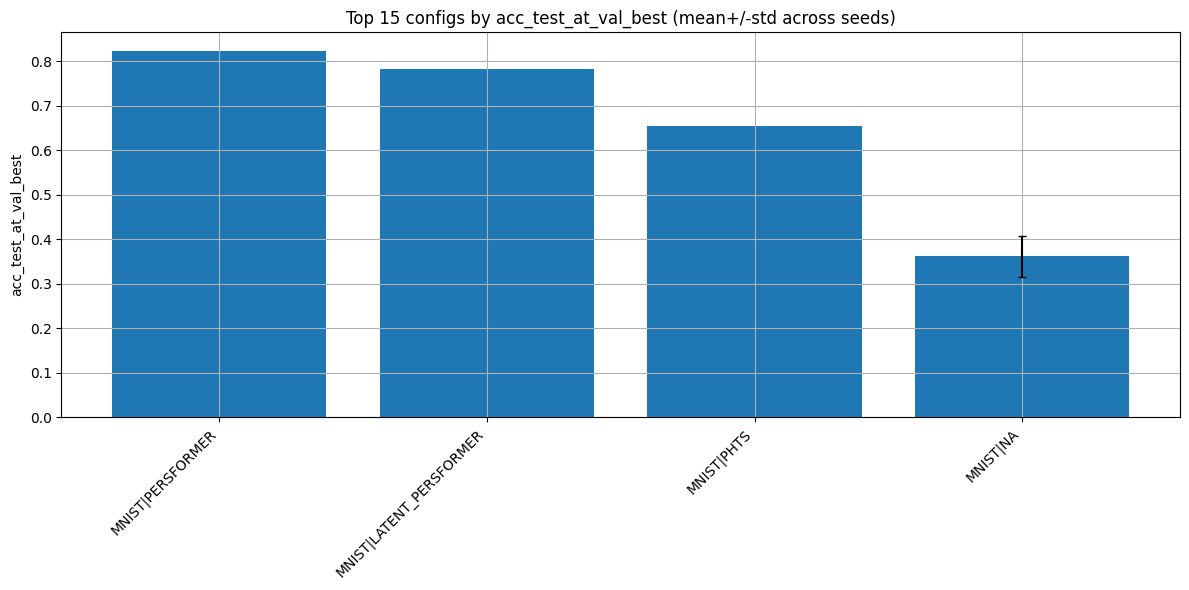

In [15]:
# --- Cell 4: Best metrics table ---

best_metric_key = "acc_test_at_val_best"
unique_run_ids = runs_df["run_id"].dropna().unique().tolist()

best_records = []

for i, run_id in enumerate(unique_run_ids):
    if (i % 10) == 0:
        print(f"Best extraction: {i}/{len(unique_run_ids)}")

    row0 = runs_df[runs_df["run_id"] == run_id].iloc[0]
    config_key = row0["config_key"]
    dataset = row0["dataset"]
    seed = row0["seed"]
    model = row0["model"]

    cache_file = runs_cache_dir / f"{run_id}__{best_metric_key}__best.csv"
    best_val = None
    if cache_file.exists():
        try:
            best_val = float(pd.read_csv(cache_file)["value"].iloc[0])
        except Exception:
            best_val = None

    if best_val is None:
        hist = client.get_metric_history(run_id, best_metric_key)
        if hist:
            # Most commonly it's a single value. If multiple points exist, take the last.
            best_val = float(hist[-1].value)
        else:
            best_val = None

        try:
            pd.DataFrame([{ "value": best_val }]).to_csv(cache_file, index=False)
        except Exception:
            pass

    best_records.append(
        {
            "run_id": run_id,
            "config_key": config_key,
            "dataset": dataset,
            "model": model,
            "seed": seed,
            best_metric_key: best_val,
        }
    )

best_df = pd.DataFrame(best_records)
print("best_df rows:", len(best_df))
print("Non-null best:", best_df[best_metric_key].notna().sum())

# Aggregate across seeds per config_key
best_summary = (
    best_df.dropna(subset=[best_metric_key])
    .groupby(["config_key"], as_index=False)
    .agg(best_mean=(best_metric_key, "mean"), best_std=(best_metric_key, "std"), n_seeds=(best_metric_key, "count"))
)

meta_cols = ["dataset", "model"]
meta = runs_df[["config_key"] + meta_cols].drop_duplicates("config_key")
best_summary = best_summary.merge(meta, on="config_key", how="left")

# Sort by mean acc desc
best_summary = best_summary.sort_values("best_mean", ascending=False)

print("Top configs by best acc:")
display(best_summary.head(20))

# Quick bar plot for the top-N
plot_top_n = 15
plot_df = best_summary.head(plot_top_n).copy()

fig, ax = plt.subplots(figsize=(12, 6))
labels = (plot_df["dataset"].fillna("NA") + "|" + plot_df["model"].fillna("NA")).tolist()
ax.bar(range(len(plot_df)), plot_df["best_mean"], yerr=plot_df["best_std"], capsize=3)
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel(best_metric_key)
ax.set_title(f"Top {plot_top_n} configs by {best_metric_key} (mean+/-std across seeds)")
plt.tight_layout()
plt.show()


Plot configs from best_summary: 4


/var/folders/sw/4qr_mf6j4xjfzk43fvclv4w00000gn/T/ipykernel_99814/809209722.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best", fontsize=9)


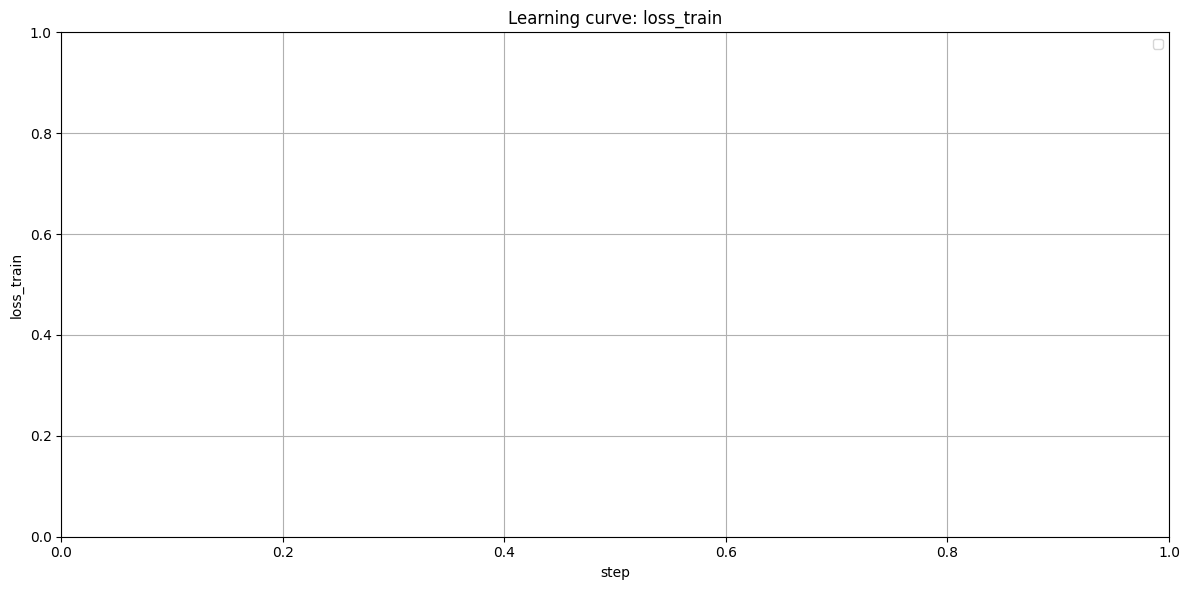

/var/folders/sw/4qr_mf6j4xjfzk43fvclv4w00000gn/T/ipykernel_99814/809209722.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best", fontsize=9)


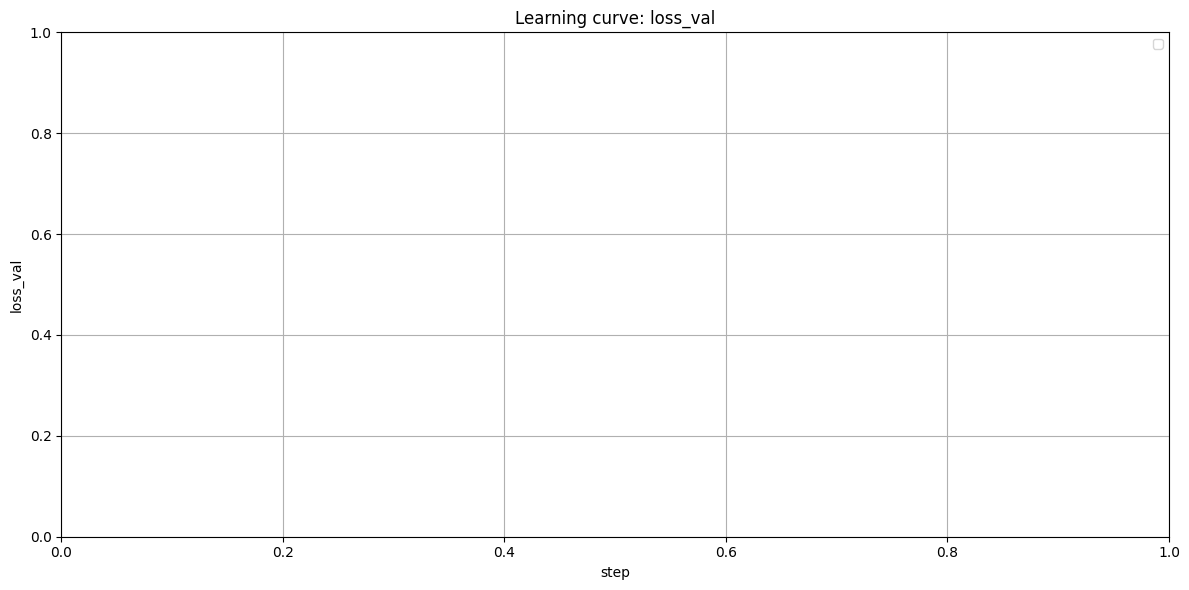

In [16]:
# --- Cell 5: Learning curves (loss_train / loss_val) ---

if series_df.empty:
    print("series_df is empty: time-series metrics not found or not logged per step.")
else:
    # Choose configs to plot
    metric_keys_to_plot = ["loss_train", "loss_val"]

    # Prefer configs with best acc (if available), otherwise pick by coverage.
    if "best_summary" in globals() and not best_summary.empty:
        configs_to_plot = best_summary["config_key"].head(8).tolist()
        print("Plot configs from best_summary:", len(configs_to_plot))
    else:
        # Fallback: pick configs with the most series points for loss_train
        coverage = (
            series_df[series_df["metric_key"] == "loss_train"]
            .groupby("config_key", as_index=False)["value"]
            .count()
            .rename(columns={"value": "n_points"})
            .sort_values("n_points", ascending=False)
        )
        configs_to_plot = coverage["config_key"].head(8).tolist()
        print("Plot configs from loss_train coverage:", len(configs_to_plot))

    # How aggressively to filter steps by frequency across seeds
    min_step_fraction = 0.5  # keep steps seen in at least 50% of runs for the metric

    def plot_metric(metric_key: str):
        sub = series_df[series_df["metric_key"] == metric_key].copy()
        if sub.empty:
            print(f"No time-series points for {metric_key}.")
            return

        n_seeds_by_cfg = sub.groupby("config_key")["seed"].nunique().to_dict()

        fig, ax = plt.subplots(figsize=(12, 6))

        for ck in configs_to_plot:
            sdf = sub[sub["config_key"] == ck].copy()
            if sdf.empty:
                continue

            # numeric seed count
            n_seeds = n_seeds_by_cfg.get(ck, 1)
            min_count = max(2, int(np.ceil(min_step_fraction * n_seeds)))

            # Count how many distinct seeds reported this step
            seed_step_counts = (
                sdf.groupby("step")["seed"].nunique().reset_index(name="n_seeds_at_step")
            )
            keep_steps = seed_step_counts[seed_step_counts["n_seeds_at_step"] >= min_count]["step"].tolist()
            sdf = sdf[sdf["step"].isin(keep_steps)]
            if sdf.empty:
                continue

            agg = sdf.groupby("step", as_index=False)["value"].agg(mean="mean", std="std")

            # Label
            row = runs_df[runs_df["config_key"] == ck].drop_duplicates("config_key")
            dataset = row["dataset"].iloc[0] if not row.empty else "NA"
            model = row["model"].iloc[0] if not row.empty else "NA"
            label = f"{dataset}|{model}"

            ax.plot(agg["step"], agg["mean"], label=label)
            if "std" in agg.columns:
                ax.fill_between(agg["step"], agg["mean"] - agg["std"], agg["mean"] + agg["std"], alpha=0.15)

        ax.set_title(f"Learning curve: {metric_key}")
        ax.set_xlabel("step")
        ax.set_ylabel(metric_key)
        ax.legend(loc="best", fontsize=9)
        plt.tight_layout()
        plt.show()

    for mk in metric_keys_to_plot:
        plot_metric(mk)


In [17]:
# --- Cell 6: Coverage / diagnostics ---

if series_df.empty:
    print("No time-series extracted for loss_train/loss_val.")
else:
    diag = (
        series_df.groupby(["config_key", "metric_key"], as_index=False)
        .agg(n_runs=("run_id", "nunique"), n_points=("value", "count"), n_steps=("step", "nunique"))
        .sort_values(["metric_key", "n_runs"], ascending=[True, False])
    )
    print("series_df rows:", len(series_df))
    display(diag.head(20))

    # Show which metrics are missing entirely
    found_metrics = sorted(series_df["metric_key"].unique().tolist())
    required = ["loss_train", "loss_val"]
    print("Found metrics:", found_metrics)
    missing = [m for m in required if m not in found_metrics]
    if missing:
        print("Missing metrics (no series found):", missing)


series_df rows: 12


,config_key,metric_key,n_runs,n_points,n_steps
2,"MNIST|NA|None|0.0|[0, 2, 4, 6, 7, 9, 11, 13, 1...",loss_train,3,3,1
0,"MNIST|LATENT_PERSFORMER|None|0.0|[0, 2, 4, 6, ...",loss_train,1,1,1
4,"MNIST|PERSFORMER|None|0.0|[0, 2, 4, 6, 7, 9, 1...",loss_train,1,1,1
6,"MNIST|PHTS|None|0.0|[0, 2, 4, 6, 7, 9, 11, 13,...",loss_train,1,1,1
3,"MNIST|NA|None|0.0|[0, 2, 4, 6, 7, 9, 11, 13, 1...",loss_val,3,3,1
1,"MNIST|LATENT_PERSFORMER|None|0.0|[0, 2, 4, 6, ...",loss_val,1,1,1
5,"MNIST|PERSFORMER|None|0.0|[0, 2, 4, 6, 7, 9, 1...",loss_val,1,1,1
7,"MNIST|PHTS|None|0.0|[0, 2, 4, 6, 7, 9, 11, 13,...",loss_val,1,1,1


Found metrics: ['loss_train', 'loss_val']
